In [1]:
# --- metacells 0.9.5 <-> pandas 3 compatibility shims ---
# pandas 3 stores strings as ExtensionArrays (StringArray) rather than object
# ndarrays; metacells 0.9.5 assumes ndarrays in several utility functions.
# Safe to re-run: the patches are unwrapped and rebuilt from the originals.
import numpy as np
import pandas as pd
import metacells.utilities as mcu
import metacells.utilities.typing as mct


def _as_numpy(shaped):
    """pandas 3 stores strings as ExtensionArrays; metacells 0.9.5 assumes ndarrays."""
    if isinstance(shaped, (pd.DataFrame, pd.Series, pd.Index)):
        shaped = shaped.values
    if isinstance(shaped, pd.api.extensions.ExtensionArray) and not isinstance(
        shaped, pd.Categorical
    ):
        dtype = object if pd.api.types.is_string_dtype(shaped.dtype) else None
        return np.asarray(shaped, dtype=dtype)
    return None


def _convert_first(original):
    """Wrap `original` so ExtensionArray input is converted to an ndarray first."""

    def wrapper(shaped):
        converted = _as_numpy(shaped)
        return original(shaped if converted is None else converted)

    wrapper._shim_wraps = original
    return wrapper


def _skip_extension_arrays(original, result):
    """ExtensionArrays have no writeable flag: report them frozen, skip (un)freezing."""

    def wrapper(shaped):
        if _as_numpy(shaped) is not None:
            return result
        return original(shaped)

    wrapper._shim_wraps = original
    return wrapper


_SHIMS = {
    "mustbe_numpy_vector": lambda original: _convert_first(original),
    "shaped_dtype": lambda original: _convert_first(original),
    "frozen": lambda original: _skip_extension_arrays(original, True),
    "freeze": lambda original: _skip_extension_arrays(original, None),
    "unfreeze": lambda original: _skip_extension_arrays(original, None),
}

# Patch both modules: call sites use `ut.` (metacells.utilities, populated by `import *`)
# as well as `utt.` (metacells.utilities.typing), which are separate bindings to the same
# function. Unwrap anything this cell patched earlier so that re-running it re-wraps the
# ORIGINALS -- wrapping the wrappers would recurse until the stack blows.
for _name, _build_shim in _SHIMS.items():
    _original = getattr(mct, _name)
    _original = getattr(_original, "_shim_wraps", _original)
    _shim = _build_shim(_original)
    setattr(mct, _name, _shim)
    setattr(mcu, _name, _shim)
# --- end shims ---

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import metacells as mc
import anndata as ad
import os
import scipy.sparse as sp
import shutil
from math import hypot

In [2]:
cells = sc.read_h5ad(
    "/mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Pre_metacells_prepped_data/prepped_data_for_metacells.h5ad"
)

cells.var["full_id"] = cells.var_names
cells.var_names = cells.var_names.str.replace(r"\.Wm82\.a4\.v1$", "", regex=True)
cells.var_names_make_unique()
cells

AnnData object with n_obs × n_vars = 30399 × 29915
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'pctCP', 'pctMT', 'nUMI_raw', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'treatment', 'libraries', 'replicate', 'source_rds', 'integrated_snn_res.0.5', 'celltype_call', 'cluster_annot', 'n_genes'
    var: 'highly_variable', 'in_integrated', 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'full_id'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'pca_loadings', 'source'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

In [3]:
LATERAL_GENE_NAMES = pd.read_csv(
    "/mnt/c/Users/mikep/Data/Soybean/Soybean_reference_info/Soybean_cell_cycle_genes.csv"
)
LATERAL_GENE_NAMES = LATERAL_GENE_NAMES["Gene ID"].to_list()

In [4]:
mc.pl.mark_lateral_genes(
    cells,
    lateral_gene_names=LATERAL_GENE_NAMES,
)

set unnamed.var[lateral_gene]: 70 true (0.234%) out of 29915 bools


In [5]:
max_parallel_piles = mc.pl.guess_max_parallel_piles(cells)

In [6]:
# max_paralle_piles = 9
# mc.pl.set_max_parallel_piles(max_parallel_piles)

In [7]:
with mc.ut.progress_bar():
    mc.pl.divide_and_conquer_pipeline(cells, random_seed=476)

Detect rare gene modules...
  0%|          [00:00]/home/mikep/Linux_conda/envs/Metacells2/lib/python3.14/site-packages/metacells/utilities/computation.py:1563: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  result = np.reciprocal(mean_per_element, where=~zeros_mask)
/home/mikep/Linux_conda/envs/Metacells2/lib/python3.14/site-packages/metacells/utilities/computation.py:1563: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  result = np.reciprocal(mean_per_element, where=~zeros_mask)
/home/mikep/Linux_conda/envs/Metacells2/lib/python3.14/site-packages/metacells/utilities/computation.py:1563: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  result = np.reciprocal(mean_per_element, where=~zeros_mask)
/home/mikep/Linux_conda/envs/Metacells2/lib/python3.14/site-packages/metacells/u

In [8]:
import os

# Outputs mirror the SEACells run layout so the two approaches stay comparable.
METACELLS_DIR = "/mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2"
os.makedirs(METACELLS_DIR, exist_ok=True)

FIT_PATH = os.path.join(METACELLS_DIR, "metacells2_standard_run_object_output.h5ad")
META_PATH = os.path.join(
    METACELLS_DIR, "metacells2_standard_run_metacell_summarized_output.h5ad"
)

# Collect the per-metacell profiles. metacells.layers["total_umis"] holds the summed UMIs
# per gene per metacell -- the metacells2 analogue of the SEACells layers["raw"] matrix
# the co-expression network below is built from. (metacells.X is gene *fractions*, not
# counts, so it is not what we want here.)
metacells = mc.pl.collect_metacells(cells, name="metacells2.metacells", random_seed=476)

grouped = metacells.obs["grouped"]
print(
    f"{cells.n_obs:,} cells -> {metacells.n_obs} metacells "
    f"({int(metacells.uns['outliers']):,} outlier cells left unassigned)"
)
print(
    f"  cells per metacell: min={grouped.min()}, median={grouped.median():.0f}, "
    f"max={grouped.max()}, mean={grouped.mean():.1f}"
)

cells.write_h5ad(FIT_PATH)
metacells.write_h5ad(META_PATH)
print(f"\nWrote:\n  {FIT_PATH}\n  {META_PATH}")

set metacells2.metacells.obs[grouped]: 505 int64s
set metacells2.metacells.obs[total_umis]: 505 int64s
set metacells2.metacells.layers[total_umis]: ndarray 505 X 29915 float32s
set metacells2.metacells.obs[__zeros_downsample_umis]: 505 int64s
set metacells2.metacells.layers[zeros]: ndarray 505 X 29915 int32s
set unnamed.obs[metacell_name]: 30399 <U8s
set metacells2.metacells.var[highly_variable]: 2502 true (8.364%) out of 29915 bools
set metacells2.metacells.var[in_integrated]: 2965 true (9.911%) out of 29915 bools
set metacells2.metacells.var[n_cells]: 29915 int64s
set metacells2.metacells.var[means]: 29915 float64s
set metacells2.metacells.var[dispersions]: 29915 float64s
set metacells2.metacells.var[dispersions_norm]: 29915 float32s
set metacells2.metacells.var[full_id]: 29915 objects
set metacells2.metacells.var[lateral_gene]: 70 true (0.234%) out of 29915 bools
set metacells2.metacells.var[selected_gene]: 10302 true (34.44%) out of 29915 bools
set metacells2.metacells.var[rare_gen

30,399 cells -> 505 metacells (2 outlier cells left unassigned)
  cells per metacell: min=21, median=60, max=95, mean=60.2

Wrote:
  /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2/metacells2_standard_run_object_output.h5ad
  /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2/metacells2_standard_run_metacell_summarized_output.h5ad


## Metacell co-expression network

Builds a gene-by-gene co-expression network using the metacells2 metacells as the
"samples", starting from the objects saved above so the divide-and-conquer fit does not
have to be re-run.

The method is deliberately identical to
[`../SEA_cells_construction/SEA_cells_run.ipynb`](../SEA_cells_construction/SEA_cells_run.ipynb)
so the two networks differ only in **how the cells were grouped** — rank-trick Spearman
following `build_coexpression_networks.py`, plus the methods of **CoCoCoNet**
(Lee, Harris & Gillis, *NAR* 2020, 48:W566–W571,
<https://academic.oup.com/nar/article/48/W1/W566/5835815>), which is the reference used
to settle the choices the template script left open:

| Choice | Decision | Source |
| --- | --- | --- |
| Correlation metric | Spearman, computed with the rank/centre/normalise dot-product trick | template + CoCoCoNet ("Spearman's correlation between every pair of genes... non-parametric, so outliers do not dominate") |
| Gene filter | drop genes detected (count > 0) in fewer than **25 %** of metacells | specified for this analysis; CoCoCoNet's own filters ("expressed at least once in at least half of the datasets") are dataset-count-based and do not transfer to a single-dataset network |
| Post-processing | adjacency matrix is **rank standardised and divided by the maximum rank**, putting every edge in (0, 1] | CoCoCoNet ("This generates a network that is then rank standardized and normalized by dividing through by the maximum rank") |
| Aggregation across datasets | not applicable — this is a single dataset, so there is nothing to sum before rank standardising | CoCoCoNet aggregates by summing adjacency matrices then re-rank-standardising |
| NA correlations | zero-variance genes are dropped up front (with a single dataset there is nothing to borrow from); any residual NA would be filled with the network median | CoCoCoNet ("We replace these NA values with the median value of the network") |

**Input matrix.** `mdata.layers["total_umis"]` — the summed UMIs per gene per metacell,
the metacells2 counterpart of the SEACells `layers["raw"]` matrix. Note that `mdata.X`
holds gene *fractions*, not counts, so it is not used here. Cells metacells2 flagged as
outliers are not part of any metacell and so drop out of the network input.

**Library-size normalisation.** CoCoCoNet's methods go straight from counts to Spearman
without stating whether counts were normalised. metacells2 targets a fixed UMI budget
per metacell (`target_metacell_umis=160,000`), so library sizes are more uniform here
than in the SEACells run — but Spearman ranks each gene *across* metacells, so any
residual size spread would still tilt every gene's rank vector. Metacells are therefore
**CPM-normalised per metacell**, exactly as in the SEACells notebook, so the two
networks are built the same way. No `log1p` is applied — Spearman is rank-based, so a
monotone transform would not change any edge.

**Gene labels.** Cell 1 stripped the `.Wm82.a4.v1` suffix from `var_names`, so the
network is written out using `var["full_id"]` instead. That matches the SEACells network
and the `Glyma.*.Wm82.a4.v1` → NCBI `LocusTag` mapping the conservation notebook relies
on.

In [9]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as sci
import h5py

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)  # pipeline below is deterministic; set for consistency

METACELLS_DIR = "/mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2"
META_PATH = os.path.join(
    METACELLS_DIR, "metacells2_standard_run_metacell_summarized_output.h5ad"
)

MIN_METACELL_FRACTION = 0.25  # keep genes detected in >= 25% of metacells
RANK_CHUNK_ROWS = 500  # rows per chunk when rank standardising the network

# ---------------------------------------------------------------- read objects
# Re-read from disk rather than relying on the in-memory object so this cell can be
# re-run on a fresh kernel without repeating the divide-and-conquer fit.
metacells = sc.read_h5ad(META_PATH)
grouped = np.asarray(metacells.obs["grouped"], dtype=float)
print(
    f"Summarized object: {metacells.n_obs} metacells x {metacells.n_vars:,} genes "
    f"({int(metacells.uns['outliers']):,} outlier cells excluded by metacells2)"
)
print(
    f"  cells per metacell: min={grouped.min():.0f}, median={np.median(grouped):.0f}, "
    f"max={grouped.max():.0f}, mean={grouped.mean():.1f}"
)

NETWORK_PATH = os.path.join(
    METACELLS_DIR, f"metacells2_{metacells.n_obs}_metacell_coexpression_network.h5"
)

# Metacell-summed counts (metacells x genes).
counts = metacells.layers["total_umis"]
counts = counts.toarray() if sp.issparse(counts) else np.asarray(counts)
counts = counts.astype(np.float64)

# Label genes with their full Phytozome IDs -- cell 1 stripped the ".Wm82.a4.v1" suffix
# from var_names, but the SEACells network and the downstream conservation notebook both
# key on the full form.
gene_names = np.asarray(
    metacells.var["full_id"] if "full_id" in metacells.var else metacells.var_names,
    dtype=object,
)
n_metacells = counts.shape[0]

# ---------------------------------------------------------------- gene filter
min_metacells = int(np.ceil(MIN_METACELL_FRACTION * n_metacells))
detected_in = (counts > 0).sum(axis=0)
keep = detected_in >= min_metacells
print(
    f"\nGene filter: keeping genes detected in >= {MIN_METACELL_FRACTION:.0%} of "
    f"metacells ({min_metacells}/{n_metacells})"
)
print(
    f"  {int(keep.sum()):,} of {keep.size:,} genes kept "
    f"({int((~keep).sum()):,} dropped)"
)
counts = counts[:, keep]
gene_names = gene_names[keep]

# --------------------------------------------- CPM normalisation per metacell
# CoCoCoNet is silent on library-size normalisation, and metacells2 targets a fixed UMI
# budget per metacell (target_metacell_umis=160,000) so sizes are more uniform here than
# in the SEACells run -- but Spearman ranks each gene *across* metacells, so any residual
# size spread would still tilt the ranks. Normalised anyway, identically to the SEACells
# network, so the two are built the same way.
lib_sizes = counts.sum(axis=1)
print(
    f"\nMetacell library sizes: min={lib_sizes.min():,.0f}, "
    f"median={np.median(lib_sizes):,.0f}, max={lib_sizes.max():,.0f} "
    f"({lib_sizes.max() / lib_sizes.min():.1f}x spread)"
)
expr = (counts / lib_sizes[:, None]) * 1e6
del counts

# ------------------------------------------------------- Spearman correlation
# Same rank trick as build_coexpression_networks.py: rank each gene across samples,
# centre, scale to unit length, then the dot product of the rows is Spearman's rho.
expr = expr.T  # genes x metacells, matching the template's row-wise ranking
print(f"\nRanking {expr.shape[0]:,} genes across {expr.shape[1]} metacells ...")
ranks = sci.rankdata(expr, method="average", axis=1)
del expr

# Average ranks always sum to n(n+1)/2, so every gene's mean rank is (n+1)/2 even
# with ties (metacell data has plenty of tied zeros).
ranks -= (n_metacells + 1) / 2.0
norms = np.sqrt(np.square(ranks).sum(axis=1))

# A zero norm means a constant rank vector (no variance) -> correlation undefined.
# CoCoCoNet fills such NAs with the network median, but that only makes sense when
# aggregating over datasets; with a single dataset the gene carries no information,
# so drop it instead.
variable = norms > 0
if not variable.all():
    print(f"  dropping {int((~variable).sum()):,} zero-variance genes")
    ranks = ranks[variable]
    norms = norms[variable]
    gene_names = gene_names[variable]

ranks = (ranks / norms[:, None]).astype(np.float32)
del norms

n_genes = ranks.shape[0]
print(
    f"Computing {n_genes:,} x {n_genes:,} Spearman correlations "
    f"(~{n_genes ** 2 * 4 / 1e9:.2f} GB, float32) ..."
)
network = ranks @ ranks.T
del ranks

# Defensive: with zero-variance genes removed there should be no NAs left, but if any
# survive, fill them with the median network value the way CoCoCoNet does.
n_nan = int(np.isnan(network).sum())
if n_nan:
    median_value = np.nanmedian(network)
    print(
        f"  filling {n_nan:,} NA correlations with the network median "
        f"({median_value:.4f})"
    )
    np.nan_to_num(network, copy=False, nan=median_value)
np.clip(network, -1.0, 1.0, out=network)  # tidy up float error at the extremes

# --------------------------------------------------- CoCoCoNet standardisation
# "rank standardized and normalized by dividing through by the maximum rank".
# Done with a sorted copy plus chunked searchsorted so peak memory stays at roughly
# two copies of the matrix rather than the ~4 copies np.argsort would need.
print("Rank standardising the adjacency matrix ...")
flat = network.reshape(-1)
sorted_values = np.sort(flat)
n_edges = sorted_values.size
# Maximum average rank: ties at the top share the mean of their positions.
top_left = int(np.searchsorted(sorted_values, sorted_values[-1], side="left"))
max_rank = (top_left + n_edges + 1) / 2.0

for start in range(0, n_genes, RANK_CHUNK_ROWS):
    stop = min(start + RANK_CHUNK_ROWS, n_genes)
    block = network[start:stop].reshape(-1)
    lo = np.searchsorted(sorted_values, block, side="left")
    hi = np.searchsorted(sorted_values, block, side="right")
    network[start:stop] = (((lo + hi + 1) / 2.0) / max_rank).reshape(
        stop - start, n_genes
    )
del sorted_values

np.fill_diagonal(network, 1.0)  # keep self-edges at the top of the scale
print(
    f"  edge weights now span {network.min():.6f} to {network.max():.6f} "
    f"(median {np.median(network):.4f})"
)

# ------------------------------------------------------------------- save out
# Same on-disk layout as the SEACells network: the matrix and its gene labels as two
# plain datasets (h5py rather than DataFrame.to_hdf, which would need pytables and an
# extra in-memory copy). Read it back with the loader defined below.
with h5py.File(NETWORK_PATH, "w") as handle:
    handle.create_dataset("network", data=network, dtype="float32")
    handle.create_dataset(
        "genes", data=gene_names.astype(object), dtype=h5py.string_dtype()
    )
    handle["network"].attrs["metric"] = "spearman"
    handle["network"].attrs["postprocessing"] = "rank standardized / max rank"
    handle["network"].attrs["normalization"] = "CPM per metacell"
    handle["network"].attrs["min_metacell_fraction"] = MIN_METACELL_FRACTION
    handle["network"].attrs["n_metacells"] = n_metacells
    handle["network"].attrs["grouping"] = str(
        metacells.uns.get("metacells_algorithm", "metacells")
    )

print(
    f"\nSaved {n_genes:,} x {n_genes:,} network "
    f"({os.path.getsize(NETWORK_PATH) / 1e9:.2f} GB) to:\n  {NETWORK_PATH}"
)


def load_coexpression_network(path=NETWORK_PATH, genes=None):
    """Read the saved network back. Pass `genes` to pull only those rows/columns,
    which avoids loading the full matrix when you only want a few genes."""
    with h5py.File(path, "r") as handle:
        all_genes = handle["genes"].asstr()[:]
        if genes is None:
            values = handle["network"][:]
            labels = all_genes
        else:
            lookup = {gene: i for i, gene in enumerate(all_genes)}
            missing = [g for g in genes if g not in lookup]
            if missing:
                raise KeyError(f"not in the network: {missing}")
            idx = np.sort([lookup[g] for g in genes])
            values = handle["network"][idx][:, idx]
            labels = all_genes[idx]
    return pd.DataFrame(values, index=labels, columns=labels)


# Preview the top-left corner without materialising a second copy of the matrix.
pd.DataFrame(network[:5, :5], index=gene_names[:5], columns=gene_names[:5])

Summarized object: 505 metacells x 29,915 genes (2 outlier cells excluded by metacells2)
  cells per metacell: min=21, median=60, max=95, mean=60.2

Gene filter: keeping genes detected in >= 25% of metacells (127/505)
  22,123 of 29,915 genes kept (7,792 dropped)

Metacell library sizes: min=37,356, median=115,408, max=231,598 (6.2x spread)

Ranking 22,123 genes across 505 metacells ...
Computing 22,123 x 22,123 Spearman correlations (~1.96 GB, float32) ...
Rank standardising the adjacency matrix ...
  edge weights now span 0.000000 to 1.000000 (median 0.5000)

Saved 22,123 x 22,123 network (1.96 GB) to:
  /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2/metacells2_505_metacell_coexpression_network.h5


,Glyma.01G161700.Wm82.a4.v1,Glyma.03G158766.Wm82.a4.v1,Glyma.03G058100.Wm82.a4.v1,Glyma.09G060300.Wm82.a4.v1,Glyma.08G294100.Wm82.a4.v1
Glyma.01G161700.Wm82.a4.v1,1.000000,0.609221,0.698411,0.782441,0.945175
Glyma.03G158766.Wm82.a4.v1,0.609221,1.000000,0.237552,0.689924,0.184614
Glyma.03G058100.Wm82.a4.v1,0.698411,0.237552,1.000000,0.548520,0.527750
Glyma.09G060300.Wm82.a4.v1,0.782441,0.689924,0.548520,1.000000,0.585250
Glyma.08G294100.Wm82.a4.v1,0.945175,0.184614,0.527750,0.585250,1.000000


# Co-expression conservation: metacells2 network vs. bulk soybean network

Compares the metacell co-expression network built above (metacells2 metacells as
samples) against the bulk-derived aggregate network `soybean_prioAggNet.hdf5`.

Same procedure as
[`../Coexpression_conservation/metacell_vs_bulk_conservation.ipynb`](../Coexpression_conservation/metacell_vs_bulk_conservation.ipynb),
which scores the SEACells network, so the two numbers are directly comparable.

Method follows the Gillis lab **fine-to-bulk co-expression conservation** approach:
[`Coecoexpression_conservation_fine_to_bulk.ipynb`](https://github.com/gillislab/Coexpression_Proxies/blob/main/Coexpression_Network_Generation/Coecoexpression_conservation_fine_to_bulk.ipynb).

For every gene, take its **top 10 partners in the bulk network**, then ask where those
10 genes rank in that gene's column of the **metacell network**. If the metacell
network recovers the same partners they sit at the top of the ranking and the score is
near 1; if it ranks them randomly the score drops toward 0.

| Step | What happens |
| --- | --- |
| 1 | Subset `All_Plants.gene_info` to *Glycine max* (taxid 3847) |
| 2 | Map `Glyma.*.Wm82.a4.v1` to the bulk network's NCBI names via the `LocusTag` field |
| 3 | Load both networks restricted to the shared genes, in matching order |
| 4 | Zero the diagonals; build the top-10 partner mask from the bulk network |
| 5 | Rank each column of the metacell network; `mask . ranks`; take the diagonal |
| 6 | Normalise, take the median, plot the distribution |

**Reference point:** the same procedure applied to Arabidopsis (fine single-cell
pseudobulk vs. bulk CoCoCoNet) gave a median conservation of **0.863**.

In [10]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as sci
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)

GENE_INFO_ALL = "/mnt/c/Users/mikep/Data/NCBI/All_Plants.gene_info"
GENE_INFO_SOY = "/mnt/c/Users/mikep/Data/NCBI/Glycine_max_3847.gene_info.csv"
BULK_NET = (
    "/mnt/c/Users/mikep/Data/Soybean/Soybean_reference_info/soybean_prioAggNet.hdf5"
)
METACELLS_DIR = "/mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2"
SCORES_OUT = "../Coexpression_conservation/metacells2_vs_bulk_conservation_scores.csv"

# The network filename carries the metacell count, which is only known once the fit has
# run, so resolve it rather than hard-coding it.
_networks = sorted(
    glob.glob(
        os.path.join(METACELLS_DIR, "metacells2_*_metacell_coexpression_network.h5")
    )
)
assert (
    len(_networks) == 1
), f"expected one metacells2 network in {METACELLS_DIR}, found {_networks}"
META_NET = _networks[0]
print(f"Metacell network: {META_NET}")

GLYCINE_MAX_TAXID = 3847
TOP_N_PARTNERS = 10  # size of the bulk-network partner set, per the reference notebook
READ_CHUNK_ROWS = 500  # rows per slab when pulling the bulk network off disk
DOT_CHUNK_COLS = 1000  # columns per chunk in the mask-by-ranks product

Metacell network: /mnt/c/Users/mikep/Data/Soybean/Metacells_approaches/Metacells2/metacells2_505_metacell_coexpression_network.h5


## Step 1 — subset NCBI `gene_info` to *Glycine max*

`All_Plants.gene_info` is ~1.5 GB, so it is streamed in chunks, filtered to taxid 3847,
and cached to CSV. Re-runs read the cache (already written by the SEACells conservation
notebook).

In [11]:
if os.path.exists(GENE_INFO_SOY):
    gene_info = pd.read_csv(GENE_INFO_SOY, dtype=str)
    print(f"Loaded cached Glycine max gene_info: {len(gene_info):,} rows")
else:
    print(f"Streaming {GENE_INFO_ALL} and filtering to taxid {GLYCINE_MAX_TAXID} ...")
    kept = []
    for chunk in pd.read_csv(
        GENE_INFO_ALL, sep="\t", dtype=str, chunksize=500_000, low_memory=False
    ):
        chunk = chunk.rename(columns={"#tax_id": "tax_id"})
        kept.append(chunk[chunk["tax_id"] == str(GLYCINE_MAX_TAXID)])
    gene_info = pd.concat(kept, ignore_index=True)
    gene_info.to_csv(GENE_INFO_SOY, index=False)
    print(f"Cached {len(gene_info):,} Glycine max rows to {GENE_INFO_SOY}")

print(f"\ngene_info columns: {list(gene_info.columns)}")
gene_info[["GeneID", "Symbol", "LocusTag", "description", "type_of_gene"]].head()

Loaded cached Glycine max gene_info: 59,141 rows

gene_info columns: ['tax_id', 'GeneID', 'Symbol', 'LocusTag', 'Synonyms', 'dbXrefs', 'chromosome', 'map_location', 'description', 'type_of_gene', 'Symbol_from_nomenclature_authority', 'Full_name_from_nomenclature_authority', 'Nomenclature_status', 'Other_designations', 'Modification_date', 'Feature_type']


,GeneID,Symbol,LocusTag,description,type_of_gene
0,547449,LOC547449,GLYMA_20G164700v4,class III acidic endochitinase,protein-coding
1,547450,SRC1,GLYMA_17G187600v4,src1 protein,protein-coding
2,547451,SRC2,GLYMA_15G152900v4,SOYBEAN GENE REGULATED BY COLD 2,protein-coding
3,547452,GY5,GLYMA_13G123500v4,glycinin gy5,protein-coding
4,547453,UR9,GLYMA_10G121524v4,uricase-2 isozyme 1,protein-coding


## Step 2 — map `Glyma` IDs to the bulk network's gene names

The two networks use different naming schemes and share **zero** names directly:

- metacell network: Phytozome/JGI, e.g. `Glyma.01G161700.Wm82.a4.v1`
- bulk network: NCBI, e.g. `LOC100808170` or a gene symbol like `MYB128`

`gene_info`'s **`LocusTag`** column is the bridge — it carries Wm82.**a4** gene models
(`GLYMA_01G161700v4`), the same assembly the metacell network is built on, so no
cross-assembly liftover is needed. The conversion is purely textual:

```
Glyma.01G161700.Wm82.a4.v1  ->  GLYMA_01G161700v4  ->  Symbol (LOC100808170 / MYB128)
```

This is why the network above is written out with `var["full_id"]` rather than the
suffix-stripped `var_names` — `glyma_to_locustag` splits on `.Wm82`.

In [12]:
def glyma_to_locustag(gene):
    """Glyma.01G161700.Wm82.a4.v1 -> GLYMA_01G161700v4 (the NCBI LocusTag form)."""
    core = gene.split(".Wm82")[0]  # Glyma.01G161700
    return "GLYMA_" + core.split(".", 1)[1] + "v4"


# gene_info can carry a LocusTag more than once; keep the first so the map stays 1:1.
locus_to_symbol = (
    gene_info.dropna(subset=["LocusTag", "Symbol"])
    .drop_duplicates(subset="LocusTag", keep="first")
    .set_index("LocusTag")["Symbol"]
    .to_dict()
)
print(f"LocusTag -> Symbol entries: {len(locus_to_symbol):,}")

with h5py.File(META_NET, "r") as handle:
    meta_genes = handle["genes"].asstr()[:]
with h5py.File(BULK_NET, "r") as handle:
    bulk_genes = handle["row"].asstr()[:]
    assert (handle["row"][:] == handle["col"][:]).all(), "bulk net rows != cols"

print(f"metacell network: {len(meta_genes):,} genes  e.g. {meta_genes[0]}")
print(f"bulk network:     {len(bulk_genes):,} genes  e.g. {bulk_genes[0]}")
print(f"direct name overlap: {len(set(meta_genes) & set(bulk_genes)):,}")

bulk_position = {gene: i for i, gene in enumerate(bulk_genes)}

# Walk the metacell genes and keep those that reach a gene present in the bulk network.
pairs = []  # (metacell gene, bulk gene, metacell index, bulk index)
no_locustag, no_bulk_entry = [], []
for meta_position, gene in enumerate(meta_genes):
    symbol = locus_to_symbol.get(glyma_to_locustag(gene))
    if symbol is None:
        no_locustag.append(gene)
    elif symbol not in bulk_position:
        no_bulk_entry.append(gene)
    else:
        pairs.append((gene, symbol, meta_position, bulk_position[symbol]))

mapping = pd.DataFrame(
    pairs, columns=["metacell_gene", "bulk_gene", "meta_idx", "bulk_idx"]
)
print(
    f"\nMapped {len(mapping):,} of {len(meta_genes):,} metacell genes "
    f"({len(mapping) / len(meta_genes):.1%})"
)
print(f"  no LocusTag match in gene_info: {len(no_locustag):,}")
print(f"  mapped but absent from bulk net: {len(no_bulk_entry):,}")

# Guard against many-to-one collapse, which would put duplicate rows in the network.
collisions = mapping["bulk_gene"].duplicated().sum()
if collisions:
    print(f"  dropping {collisions:,} metacell genes sharing a bulk gene")
    mapping = mapping.drop_duplicates(subset="bulk_gene", keep="first")

# h5py fancy indexing needs strictly increasing indices, so order by bulk position.
mapping = mapping.sort_values("bulk_idx").reset_index(drop=True)
n_shared = len(mapping)
meta_idx = mapping["meta_idx"].to_numpy()
bulk_idx = mapping["bulk_idx"].to_numpy()
shared_genes = mapping["metacell_gene"].to_numpy()
print(f"\nShared gene set for the comparison: {n_shared:,} genes")
mapping.head()

LocusTag -> Symbol entries: 40,814
metacell network: 22,123 genes  e.g. Glyma.01G161700.Wm82.a4.v1
bulk network:     40,825 genes  e.g. LOC100808170
direct name overlap: 0

Mapped 20,466 of 22,123 metacell genes (92.5%)
  no LocusTag match in gene_info: 1,613
  mapped but absent from bulk net: 44

Shared gene set for the comparison: 20,466 genes


,metacell_gene,bulk_gene,meta_idx,bulk_idx
0,Glyma.01G000322.Wm82.a4.v1,LOC106794262,16392,2
1,Glyma.01G000400.Wm82.a4.v1,LOC100781438,15953,3
2,Glyma.01G000600.Wm82.a4.v1,LOC100788220,248,4
3,Glyma.01G000900.Wm82.a4.v1,LOC100779643,15929,5
4,Glyma.01G001000.Wm82.a4.v1,LOC100499919,4400,6


## Step 3 — load both networks over the shared genes

The bulk `agg` matrix is 40,825 x 40,825 float64 — **13.3 GB** if read whole, which is
what `CococoNet_reader.read_cococonet` does. Instead each network is read in row slabs
and subset to the shared genes on the way in, so only the ~1.8 GB float32 submatrix is
ever held. Both come out in the same gene order.

In [13]:
def read_network_subset(path, dataset, index, chunk_rows=READ_CHUNK_ROWS):
    """Read a symmetric gene x gene subset without materialising the full matrix.

    `index` may be in any order; h5py needs strictly increasing row indices, so rows are
    fetched sorted and written straight to their destination slots.
    """
    order = np.argsort(index)
    sorted_index = index[order]
    size = len(index)
    out = np.empty((size, size), dtype=np.float32)
    with h5py.File(path, "r") as handle:
        dset = handle[dataset]
        for start in range(0, size, chunk_rows):
            stop = min(start + chunk_rows, size)
            block = dset[sorted_index[start:stop], :]
            out[order[start:stop]] = block[:, index].astype(np.float32)
    return out


print(
    f"Reading bulk network subset ({n_shared:,} x {n_shared:,}, "
    f"~{n_shared ** 2 * 4 / 1e9:.2f} GB) ..."
)
bulk_sub = read_network_subset(BULK_NET, "agg", bulk_idx)
print(
    f"  values span {bulk_sub.min():.6f} to {bulk_sub.max():.6f}, "
    f"median {np.median(bulk_sub):.4f}"
)

# The reference notebook zeroes self-edges with .replace(1, 0), which also clobbers any
# off-diagonal edge that happens to sit at exactly 1.0. Zero the diagonal explicitly
# instead, and report what the blunt version would have caught.
off_diagonal_ones = int((bulk_sub == 1.0).sum()) - n_shared
print(
    f"  off-diagonal edges at exactly 1.0: {off_diagonal_ones:,} "
    f"(kept here, dropped by .replace(1, 0))"
)
np.fill_diagonal(bulk_sub, 0.0)

Reading bulk network subset (20,466 x 20,466, ~1.68 GB) ...
  values span 0.000000 to 1.000000, median 0.7751
  off-diagonal edges at exactly 1.0: 0 (kept here, dropped by .replace(1, 0))


## Step 4 — top-10 partner mask from the bulk network

For each gene, the 10 strongest partners in the bulk network. Stored sparse (10 entries
per gene) rather than as the dense genes x genes frame the reference notebook builds —
identical contents, ~1.8 GB less memory.

In [14]:
# Per column, the row indices of the TOP_N_PARTNERS largest edges.
top_partners = np.argpartition(-bulk_sub, TOP_N_PARTNERS, axis=0)[:TOP_N_PARTNERS, :]
del bulk_sub  # mask is all that is needed from here on

mask = sp.csr_matrix(
    (
        np.ones(n_shared * TOP_N_PARTNERS, dtype=np.float32),
        (np.repeat(np.arange(n_shared), TOP_N_PARTNERS), top_partners.T.ravel()),
    ),
    shape=(n_shared, n_shared),
)
print(f"Top-{TOP_N_PARTNERS} mask: {mask.shape[0]:,} genes x {mask.nnz:,} edges")
print(
    f"  edges per gene: min={mask.getnnz(axis=1).min()}, "
    f"max={mask.getnnz(axis=1).max()}"
)

Top-10 mask: 20,466 genes x 204,660 edges
  edges per gene: min=10, max=10


In [15]:
print(f"Reading metacell network subset ({n_shared:,} x {n_shared:,}) ...")
meta_sub = read_network_subset(META_NET, "network", meta_idx)

# The reference notebook clips its network at 0 because it feeds in raw Spearman values.
# Ours is already rank standardised onto (0, 1], so the clip is a no-op -- and since the
# score depends only on within-column ranks, the rank standardisation itself cannot
# change the result either way.
negative_edges = int((meta_sub < 0).sum())
print(f"  negative edges needing a clip: {negative_edges:,}")
np.clip(meta_sub, 0, None, out=meta_sub)
np.fill_diagonal(meta_sub, 0.0)

# Rank down each column, in place and in chunks to avoid a float64 copy of the matrix.
print("Ranking each column of the metacell network ...")
for start in range(0, n_shared, DOT_CHUNK_COLS):
    stop = min(start + DOT_CHUNK_COLS, n_shared)
    meta_sub[:, start:stop] = sci.rankdata(
        meta_sub[:, start:stop], method="average", axis=0
    ).astype(np.float32)
print(f"  ranks span {meta_sub.min():.0f} to {meta_sub.max():.0f}")

Reading metacell network subset (20,466 x 20,466) ...
  negative edges needing a clip: 0
Ranking each column of the metacell network ...
  ranks span 1 to 20466


## Step 5 — conservation score

`mask . ranks` gives a genes x genes matrix whose **diagonal** is the quantity of
interest: for gene *g*, the summed rank — inside the metacell network's column *g* — of
the 10 genes that are *g*'s strongest partners in the bulk network.

The floor is `2 + 3 + ... + 11 = 65`: the zeroed self-edge always takes rank 1, so the
10 partners can do no better than ranks 2 through 11. The reference notebook then
divides by the spread of the **whole** matrix, so the full product is swept in column
chunks to recover its global min and max without ever holding all of it.

In [16]:
# Lowest attainable rank sum: rank 1 belongs to the zeroed self-edge.
MINIMUM_RANK_SUM = sum(range(2, TOP_N_PARTNERS + 2))
print(f"Minimum attainable rank sum: {MINIMUM_RANK_SUM}")

diagonal = np.empty(n_shared, dtype=np.float64)
global_max, global_min = -np.inf, np.inf

print("Computing mask . ranks in column chunks ...")
for start in range(0, n_shared, DOT_CHUNK_COLS):
    stop = min(start + DOT_CHUNK_COLS, n_shared)
    block = mask.dot(meta_sub[:, start:stop])
    global_max = max(global_max, float(block.max()))
    global_min = min(global_min, float(block.min()))
    diagonal[start:stop] = block[np.arange(start, stop), np.arange(stop - start)]

print(f"  full product spans {global_min:,.0f} to {global_max:,.0f}")

score_range = global_max - global_min
conservation_scores = pd.Series(
    (diagonal - MINIMUM_RANK_SUM) / score_range,
    index=shared_genes,
    name="conservation_score",
)

median_score = float(conservation_scores.median())
print(f"\nMedian conservation score: {median_score:.4f}")
print(
    f"  mean {conservation_scores.mean():.4f}, "
    f"IQR {conservation_scores.quantile(0.25):.4f}-"
    f"{conservation_scores.quantile(0.75):.4f}"
)
print(f"  range {conservation_scores.min():.4f} to {conservation_scores.max():.4f}")
print(f"\nArabidopsis fine-to-bulk reference median: 0.8626")
conservation_scores.head()

Minimum attainable rank sum: 65
Computing mask . ranks in column chunks ...
  full product spans 151 to 204,581

Median conservation score: 0.7348
  mean 0.7300, IQR 0.6225-0.8483
  range 0.0669 to 1.0002

Arabidopsis fine-to-bulk reference median: 0.8626


Glyma.01G000322.Wm82.a4.v1    0.675904
Glyma.01G000400.Wm82.a4.v1    0.596449
Glyma.01G000600.Wm82.a4.v1    0.408267
Glyma.01G000900.Wm82.a4.v1    0.667020
Glyma.01G001000.Wm82.a4.v1    0.944631
Name: conservation_score, dtype: float64

## Step 6 — distribution of conservation scores

Same figure as the reference notebook (`sns.histplot` over the diagonal), with the
median and the Arabidopsis reference median marked. Run the SEACells notebook's version
of this cell for the side-by-side comparison; the per-gene scores from both are saved to
`../Coexpression_conservation/`.

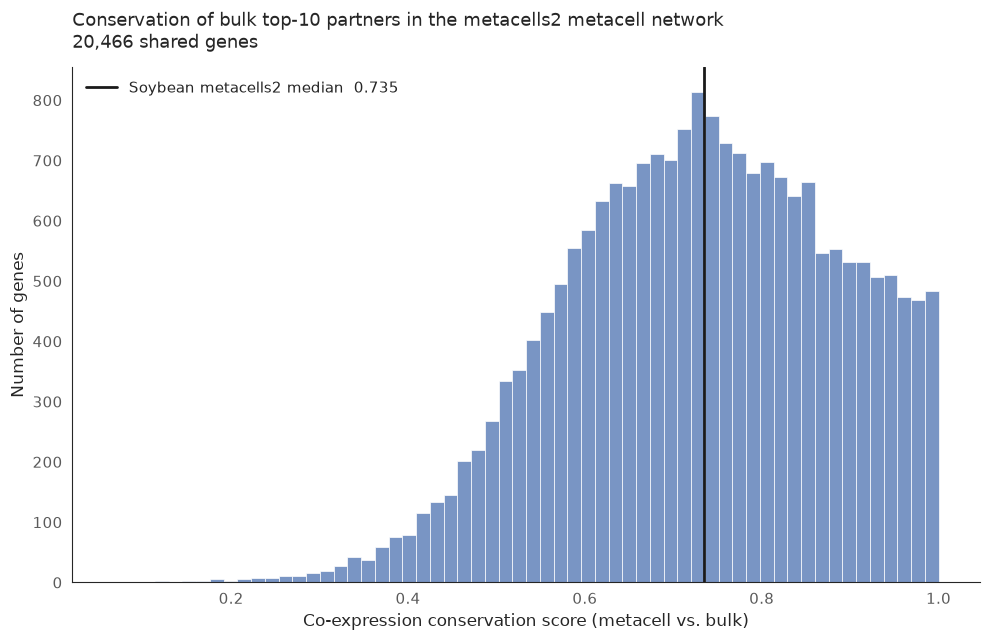

In [19]:
ARABIDOPSIS_REFERENCE_MEDIAN = 0.8626  # fine-to-bulk median from the reference notebook

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6.5))

sns.histplot(
    conservation_scores,
    bins=60,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

# Reference lines are labelled in a legend rather than inline: they can sit close
# together, and over the tallest bars, where inline text would not stay legible.
ax.axvline(
    median_score,
    color="#1A1A1A",
    linestyle="-",
    linewidth=2,
    label=f"Soybean metacells2 median  {median_score:.3f}",
)
# ax.axvline(
#     ARABIDOPSIS_REFERENCE_MEDIAN,
#     color="#8C8C8C",
#     linestyle="--",
#     linewidth=2,
#     label=f"Arabidopsis fine-to-bulk reference  {ARABIDOPSIS_REFERENCE_MEDIAN:.3f}",
# )

ax.set_xlabel("Co-expression conservation score (metacell vs. bulk)", fontsize=12)
ax.set_ylabel("Number of genes", fontsize=12)
ax.set_title(
    f"Conservation of bulk top-{TOP_N_PARTNERS} partners in the metacells2 metacell "
    f"network\n{n_shared:,} shared genes",
    fontsize=13,
    loc="left",
    pad=14,
)
ax.legend(loc="upper left", frameon=False, fontsize=11)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(labelsize=11, colors="#5A5A5A")
fig.tight_layout()
plt.show()

In [18]:
os.makedirs(os.path.dirname(SCORES_OUT), exist_ok=True)
conservation_scores.sort_values(ascending=False).to_csv(SCORES_OUT, header=True)
print(f"Saved {len(conservation_scores):,} per-gene scores to {SCORES_OUT}")

print("\nMost conserved genes:")
print(conservation_scores.nlargest(10).round(4).to_string())
print("\nLeast conserved genes:")
print(conservation_scores.nsmallest(10).round(4).to_string())

Saved 20,466 per-gene scores to ../Coexpression_conservation/metacells2_vs_bulk_conservation_scores.csv

Most conserved genes:
Glyma.15G221300.Wm82.a4.v1    1.0002
Glyma.08G181000.Wm82.a4.v1    1.0002
Glyma.02G104600.Wm82.a4.v1    1.0000
Glyma.18G106300.Wm82.a4.v1    0.9999
Glyma.14G063700.Wm82.a4.v1    0.9999
Glyma.16G211700.Wm82.a4.v1    0.9999
Glyma.07G185500.Wm82.a4.v1    0.9998
Glyma.16G033700.Wm82.a4.v1    0.9998
Glyma.08G350800.Wm82.a4.v1    0.9998
Glyma.09G135700.Wm82.a4.v1    0.9998

Least conserved genes:
Glyma.08G047800.Wm82.a4.v1    0.0669
Glyma.07G209400.Wm82.a4.v1    0.1204
Glyma.13G174300.Wm82.a4.v1    0.1249
Glyma.20G130200.Wm82.a4.v1    0.1276
Glyma.13G315900.Wm82.a4.v1    0.1378
Glyma.07G020900.Wm82.a4.v1    0.1472
Glyma.03G176100.Wm82.a4.v1    0.1479
Glyma.17G092400.Wm82.a4.v1    0.1583
Glyma.08G221600.Wm82.a4.v1    0.1632
Glyma.01G179400.Wm82.a4.v1    0.1661
